<a href="https://colab.research.google.com/github/vamsiram89/-Projects/blob/main/Amazon_web_scraping_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup Environment in Google Colab

In [39]:
!pip install requests beautifulsoup4 pandas


Import Required Libraries

In [40]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random


#extracting each product details


In [42]:
# Function to extract Product Title
def get_title(soup):

    try:
        # Outer Tag Object
        title = soup.find("span", attrs={"id":'productTitle'})

        # Inner NavigatableString Object
        title_value = title.text

        # Title as a string value
        title_string = title_value.strip()

    except AttributeError:
        title_string = ""

    return title_string

# Function to extract Product Price
def get_price(soup):

    try:
        # Most reliable: find price in the a-offscreen span
        price_element = soup.find("span", attrs={'class':'a-offscreen'})
        if price_element:
            return price_element.text.strip()
        # Fallback: sometimes the price is directly within 'a-price' span as children
        price_element = soup.find("span", attrs={'class':'a-price'})
        if price_element:
            # Extract all text from children and combine
            price_text = "".join(price_element.stripped_strings)
            return price_text
    except AttributeError:
        pass # return "" in the end
    return ""

# Function to extract Product Rating
def get_rating(soup):

    try:
        rating_element = soup.find("span", attrs={'class':'a-icon-alt'})
        if rating_element:
            return rating_element.text.strip()
    except AttributeError:
        pass # return "" in the end
    return ""

# Function to extract Number of User Reviews
def get_review_count(soup):
    try:
        review_count = soup.find("span", attrs={'id':'acrCustomerReviewText'}).string.strip()

    except AttributeError:
        review_count = ""

    return review_count

# Function to extract Availability Status
def get_availability(soup):
    try:
        available = soup.find("div", attrs={'id':'availability'})
        available = available.find("span").string.strip()

    except AttributeError:
        available = "Not Available"

    return available

In [43]:
if __name__ == '__main__':

    # add your user agent
    HEADERS = ({'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36', 'Accept-Language': 'en-US, en;q=0.5'}) # Updated User-Agent

    # The webpage URL
    URL = "https://www.amazon.in/s?k=iphone&rh=n%3A1389401031&ref=nb_sb_noss"

    print(f"Initial URL: {URL}")

    # HTTP Request
    webpage = requests.get(URL, headers=HEADERS)
    print(f"Status code for search page: {webpage.status_code}")

    # Soup Object containing all data
    soup = BeautifulSoup(webpage.content, "html.parser")

    # Fetch links as List of Tag Objects
    links = soup.find_all("a", attrs={'class':'a-link-normal s-no-outline'})

    # Store the links
    links_list = []

    # Loop for extracting links from Tag Objects
    for link in links:
            links_list.append(link.get('href'))

    print(f"Number of product links found: {len(links_list)}")
    if not links_list:
        print("No product links found on the search page. Check the URL and selectors.")

    d = {"title":[], "price":[], "rating":[], "reviews":[],"availability":[]}

    # Loop for extracting product details from each link
    for i, link in enumerate(links_list):
        time.sleep(random.uniform(1, 3)) # Add random delay
        full_url = "https://www.amazon.in" + link
        print(f"-- Processing product {i+1}/{len(links_list)}: {full_url}")

        new_webpage = requests.get(full_url, headers=HEADERS)
        print(f"---- Status code for product page: {new_webpage.status_code}")

        new_soup = BeautifulSoup(new_webpage.content, "html.parser")

        # Function calls to display all necessary product information
        title = get_title(new_soup)
        d['title'].append(title)
        d['price'].append(get_price(new_soup))
        d['rating'].append(get_rating(new_soup))
        d['reviews'].append(get_review_count(new_soup))
        d['availability'].append(get_availability(new_soup))

        print(f"---- Extracted Title: {title}")


    amazon_df = pd.DataFrame.from_dict(d)
    amazon_df['title'] = amazon_df['title'].replace('', np.nan).infer_objects(copy=False)
    amazon_df = amazon_df.dropna(subset=['title'])
    print(f"Final DataFrame shape: {amazon_df.shape}")
    amazon_df.to_csv("amazon_data.csv", header=True, index=False)

Status code for search page: 200
Number of product links found: 24
-- Processing product 1/24: https://www.amazon.in/iPhone-17e-256-GB-Starting/dp/B0GQVQY8B7/ref=sr_1_1?dib=eyJ2IjoiMSJ9.V-UhtE865OxK571cE1Lsqi6951Uap63FBbhMEWV5CZOCaSHyr9uJpo9jCMdCbeGu8lSZMHVZ_ZIoFuehNZdiHOYPZN7_pnzd_ioVNNmFTi-jYLT_gorJgYv30XpplIkD17W0-FpjBwJX-XDheMezGwiTKHCJgQw7F1D74j__VLTloKCa3yvv738t2GSzHo2LEuu0ZOy9ulTebRm5qfqVq-a58u2IUsx8kW13rv01R-SRhAKJNOn80GWR-5zL7WYfe1QufURYdIrV0VO3yNVczvF5UGPisEa6QhniOjq0w6Y.twMZSnXhKDd77l-6YfAASK-DMEFzie8eXyLWbZ8igPE&dib_tag=se&keywords=iphone&qid=1772903390&s=electronics&sr=1-1
---- Status code for product page: 200
---- Extracted Title: iPhone 17e 256 GB: 15.40 cm (6.1″) Super Retina XDR Display, A19 Chip, All-Day Battery Life, 48MP Fusion Camera, 256GB Starting Storage; Soft Pink
-- Processing product 2/24: https://www.amazon.in/iPhone-Air-256-GB-Promotion/dp/B0FQFTV1NP/ref=sr_1_2?dib=eyJ2IjoiMSJ9.V-UhtE865OxK571cE1Lsqi6951Uap63FBbhMEWV5CZOCaSHyr9uJpo9jCMdCbeGu8lSZMHVZ_ZIoFue

In [44]:
amazon_df

,title,price,rating,reviews,availability
0,iPhone 17e 256 GB: 15.40 cm (6.1″) Super Retin...,"₹64,900.00",Previous page,,"This item will be released on March 12, 2026."
1,"iPhone Air 256 GB: Thinnest iPhone Ever, 16.63...","₹93,499.00",4.3 out of 5 stars,(124),In stock
2,iPhone 17e 256 GB: 15.40 cm (6.1″) Super Retin...,"₹64,900.00",Previous page,,"This item will be released on March 12, 2026."
3,"iPhone Air 512 GB: Thinnest iPhone Ever, 16.63...","₹1,13,990.00",4.3 out of 5 stars,(124),In stock
4,"iPhone Air 1 TB: Thinnest iPhone Ever, 16.63 c...","₹1,32,490.00",4.3 out of 5 stars,(124),In stock
5,"iPhone Air 1 TB: Thinnest iPhone Ever, 16.63 c...","₹1,32,490.00",4.3 out of 5 stars,(124),In stock
6,"iPhone Air 256 GB: Thinnest iPhone Ever, 16.63...","₹93,499.00",4.3 out of 5 stars,(124),In stock
7,Samsung Galaxy S25 FE 5G Smartphone with Galax...,"₹69,299.00",4.0 out of 5 stars,(44),In stock
8,"Oppo Reno15 5G (Twilight Blue, 12GB RAM, 256GB...","₹48,999.00",4.4 out of 5 stars,(105),In stock
9,Samsung Galaxy S25 Ultra 5G Mobile with Galaxy...,"₹1,29,999.00",4.3 out of 5 stars,(976),In stock


In [45]:
import matplotlib.pyplot as plt

## Visualization 1: Bar Chart for Ratings

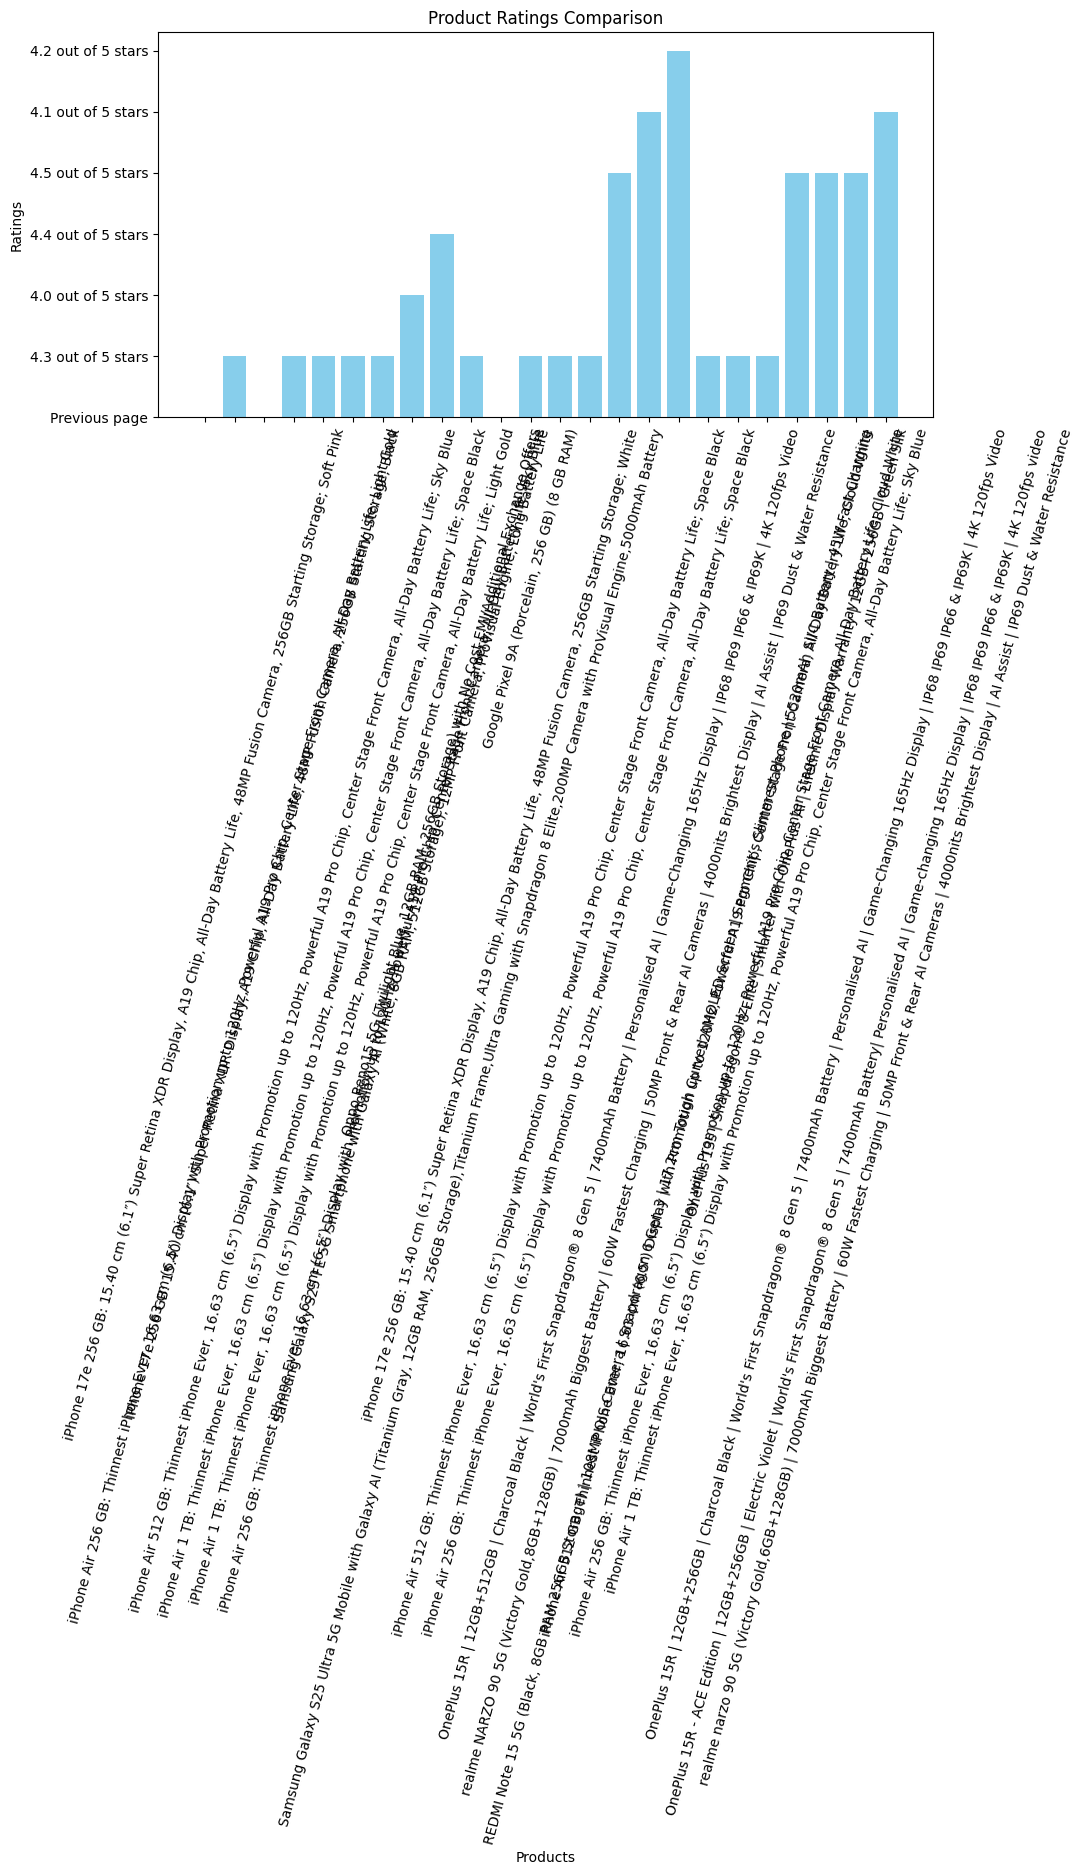

In [46]:
# 🔹 Visualization 1: Bar Chart for Ratings
plt.figure(figsize=(10, 5))
plt.bar(amazon_df["title"],amazon_df["rating"], color="skyblue")
plt.xlabel("Products")
plt.ylabel("Ratings")
plt.title("Product Ratings Comparison")
plt.xticks(rotation=75)
plt.show()

In [47]:
import plotly.express as px

fig2 = px.pie(amazon_df,
              names="availability",
              title="Product Availability",
              color="availability",
              hover_data=["title"],  # 👈 This adds product names on hover
              color_discrete_map={"In Stock": "green",
                                  "Not Available": "red",
                                  "Only 5 left in stock - order soon.": "orange",
                                  "Only 15 left in stock - order soon.": "blue"})

fig2.update_traces(hoverinfo="label+percent+text", textinfo="percent", text=amazon_df["title"])  # 👈 Customizing hover

fig2.show()


In [48]:
amazon_df

,title,price,rating,reviews,availability
0,iPhone 17e 256 GB: 15.40 cm (6.1″) Super Retin...,"₹64,900.00",Previous page,,"This item will be released on March 12, 2026."
1,"iPhone Air 256 GB: Thinnest iPhone Ever, 16.63...","₹93,499.00",4.3 out of 5 stars,(124),In stock
2,iPhone 17e 256 GB: 15.40 cm (6.1″) Super Retin...,"₹64,900.00",Previous page,,"This item will be released on March 12, 2026."
3,"iPhone Air 512 GB: Thinnest iPhone Ever, 16.63...","₹1,13,990.00",4.3 out of 5 stars,(124),In stock
4,"iPhone Air 1 TB: Thinnest iPhone Ever, 16.63 c...","₹1,32,490.00",4.3 out of 5 stars,(124),In stock
5,"iPhone Air 1 TB: Thinnest iPhone Ever, 16.63 c...","₹1,32,490.00",4.3 out of 5 stars,(124),In stock
6,"iPhone Air 256 GB: Thinnest iPhone Ever, 16.63...","₹93,499.00",4.3 out of 5 stars,(124),In stock
7,Samsung Galaxy S25 FE 5G Smartphone with Galax...,"₹69,299.00",4.0 out of 5 stars,(44),In stock
8,"Oppo Reno15 5G (Twilight Blue, 12GB RAM, 256GB...","₹48,999.00",4.4 out of 5 stars,(105),In stock
9,Samsung Galaxy S25 Ultra 5G Mobile with Galaxy...,"₹1,29,999.00",4.3 out of 5 stars,(976),In stock
